# Trabajo Práctico 1: Regresión Lineal

**Asignatura:** Aprendizaje Automático I
**Curso:** 2026 C2
**Integrantes:** Ibarbia, Colombo, Ayala

> *El código debe estar comentado: una línea por celda para su comprensión, y comentarios adicionales que justifiquen las decisiones metodológicas adoptadas.*

## 1. Objetivos

Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de regresión lineal con diversos hiperparámetros y la evaluación de métricas.

## 2. Dataset

El dataset **house-prices.csv** contiene información de precios de casas de Boston, con 14 variables (13 de entrada y 1 target). Las variables incluyen tasa de criminalidad, proporción de terrenos residenciales, concentración de óxidos de nitrógeno, número de habitaciones, entre otras.

In [3]:
# Importación de librerías necesarias para análisis, visualización y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual para los gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Resolver la ubicación del CSV buscando el repositorio y sus carpetas cercanas.
from pathlib import Path

# Se prioriza la copia versionada del repositorio para garantizar reproducibilidad sin depender de internet.
rutas_dataset = [
    Path.cwd() / 'house-prices-tp.csv',
    Path.cwd().parent / 'house-prices-tp.csv',
    Path.cwd().parent.parent / 'house-prices-tp.csv',
]
ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)

# Si se ejecuta fuera del repositorio, se mantiene una URL de respaldo correctamente identificada.
if ruta_dataset is None:
    url = 'https://raw.githubusercontent.com/manuelibarbia/TP_AAu1_Ibarbia_Colombo_Ayala/main/house-prices-tp.csv'
    df = pd.read_csv(url)
    origen_dataset = url
else:
    df = pd.read_csv(ruta_dataset)
    origen_dataset = ruta_dataset.name

# Validar que el archivo corresponde al problema de regresión planteado.
columnas_esperadas = {'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'}
faltantes = columnas_esperadas.difference(df.columns)
if faltantes:
    raise ValueError(f'Faltan columnas esperadas en el dataset: {sorted(faltantes)}')

print('Origen del dataset:', origen_dataset)
print('Dimensiones del dataset:', df.shape)
print('\nPrimeras filas:')
df.head()

Origen del dataset: house-prices-tp.csv
Dimensiones del dataset: (556, 14)

Primeras filas:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [ ]:
# Resumir tipos de datos, cardinalidad y estadísticas para conocer la estructura inicial.
print('Información del dataset:')
print('-' * 60)
df.info()

# La tabla transpuesta permite revisar rango, dispersión y escala de cada variable individualmente.
resumen_variables = df.describe().T
resumen_variables['rango'] = resumen_variables['max'] - resumen_variables['min']
resumen_variables['tipo'] = df.dtypes.astype(str)
resumen_variables['valores_unicos'] = df.nunique()
print('\nResumen descriptivo por variable:')
display(resumen_variables[['tipo', 'valores_unicos', 'min', 'max', 'rango', 'mean', 'std']].round(3))

Información del dataset:
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB

Resumen descriptivo por variable:


,tipo,valores_unicos,min,max,rango,mean,std
CRIM,float64,531,0.006,88.976,88.970,5.846,13.829
ZN,float64,54,0.000,100.000,100.000,13.197,24.903
INDUS,float64,111,0.460,27.740,27.280,11.219,6.942
CHAS,float64,2,0.000,1.000,1.000,0.090,0.287
NOX,float64,107,0.385,0.871,0.486,0.560,0.119
RM,float64,475,3.561,8.780,5.219,6.292,0.782
AGE,float64,382,2.900,100.000,97.100,67.632,28.462
DIS,float64,447,1.130,12.126,10.997,3.944,2.256
RAD,float64,31,1.000,24.000,23.000,9.699,8.684
TAX,float64,98,187.000,711.000,524.000,409.575,167.689


---

## Consigna 3: Análisis descriptivo

Se describen las variables, los faltantes, las relaciones con `MEDV` y el preprocesamiento. `CHAS` ya es una variable dummy numérica 0/1, por lo que no requiere codificación adicional.

In [ ]:
# Revisar faltantes y definir el tratamiento antes del modelado.
nulos = df.isna().sum()
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos / len(df) * 100})
display(df_nulos)

# No se imputan targets: las filas sin MEDV no tienen etiqueta supervisada.
df_modelo = df.dropna(subset=['MEDV']).copy()
print(f"Filas originales: {len(df)} | Filas sin MEDV excluidas: {len(df) - len(df_modelo)}")
print('Features faltantes: se imputarán con la mediana aprendida únicamente en train.')

,Nulos,Porcentaje (%)
CRIM,23,4.136691
ZN,22,3.956835
INDUS,15,2.697842
CHAS,23,4.136691
NOX,24,4.316547
RM,21,3.776978
AGE,24,4.316547
DIS,15,2.697842
RAD,28,5.035971
TAX,18,3.237410


Filas originales: 556 | Filas sin MEDV excluidas: 21
Features faltantes: se imputarán con la mediana aprendida únicamente en train.


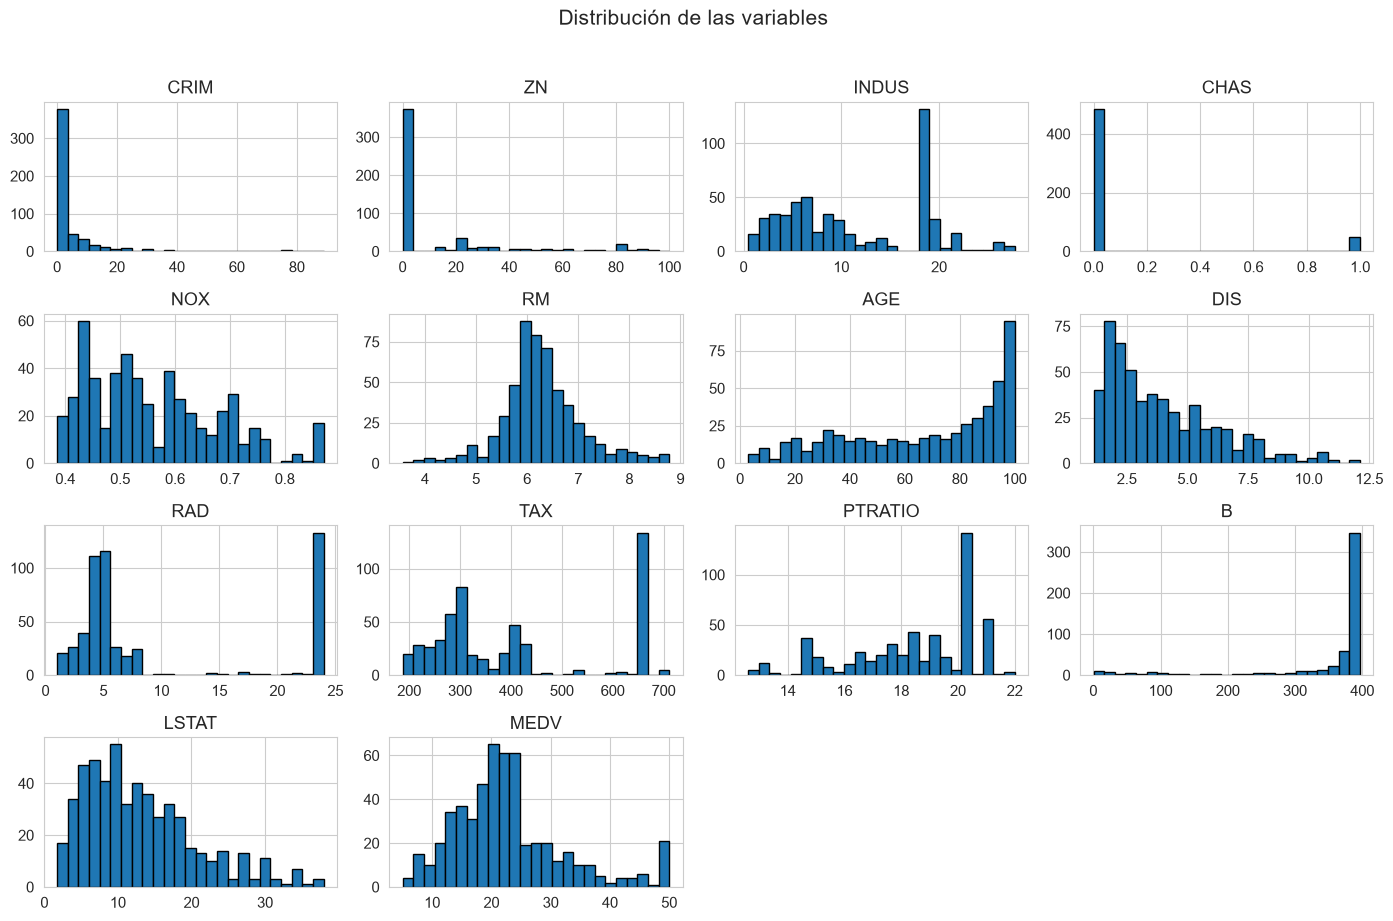

In [ ]:
# Visualizar la distribución de todas las variables en una única figura compacta.
axes = df.hist(bins=25, figsize=(14, 9), edgecolor='black')
plt.suptitle('Distribución de las variables', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

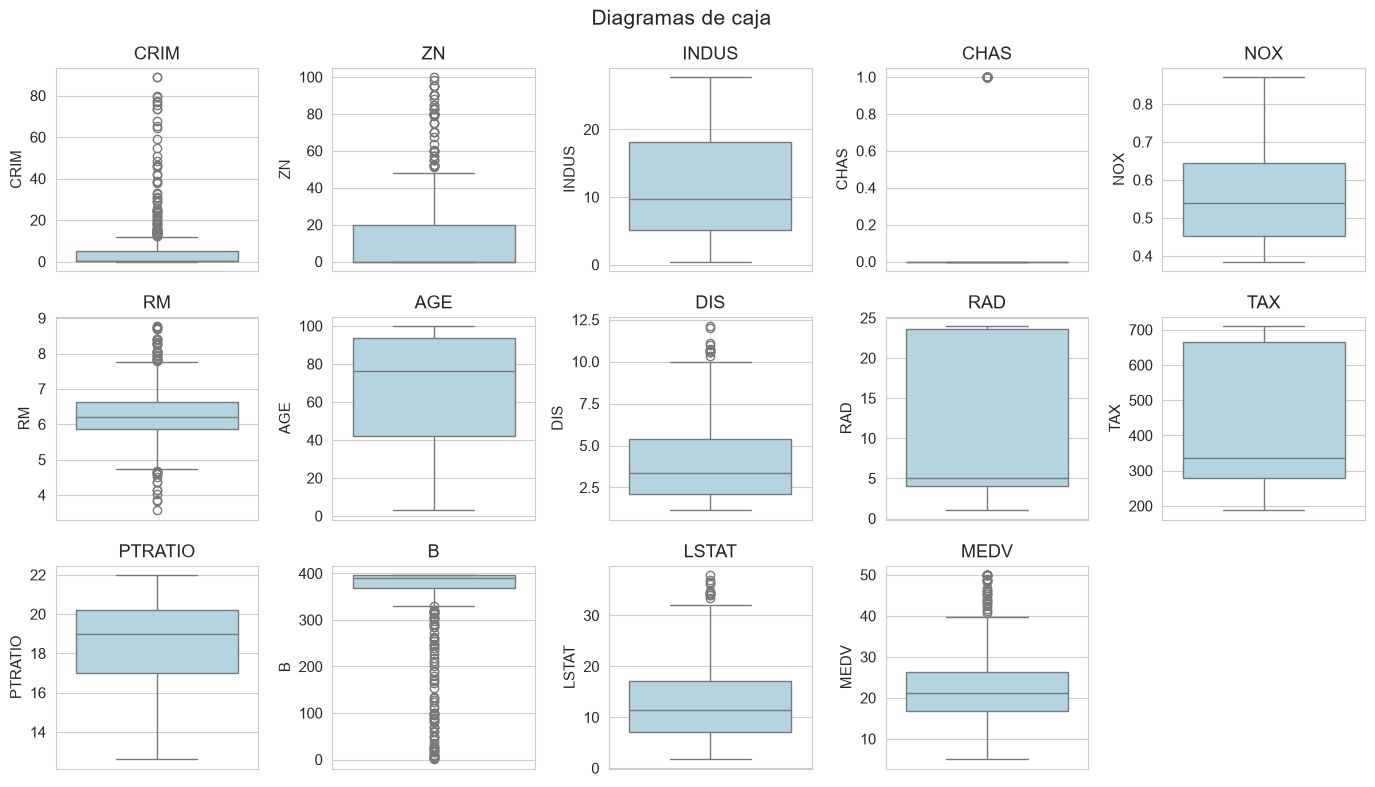

In [ ]:
# Identificar dispersión y posibles valores extremos mediante boxplots.
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for ax, col in zip(axes.flat, df.columns):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
for ax in axes.flat[len(df.columns):]:
    ax.set_visible(False)
plt.suptitle('Diagramas de caja', fontsize=15)
plt.tight_layout()
plt.show()

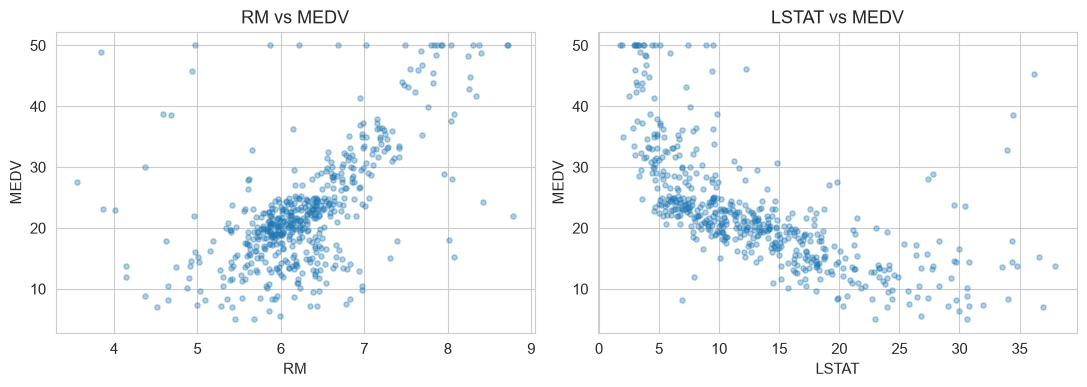

In [ ]:
# Graficar las dos variables con mayor relación lineal con MEDV según la matriz de correlación.
variables_clave = ['RM', 'LSTAT']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, variable in zip(axes, variables_clave):
    ax.scatter(df[variable], df['MEDV'], alpha=0.35, s=14)
    ax.set_xlabel(variable)
    ax.set_ylabel('MEDV')
    ax.set_title(f'{variable} vs MEDV')
plt.tight_layout()
plt.show()

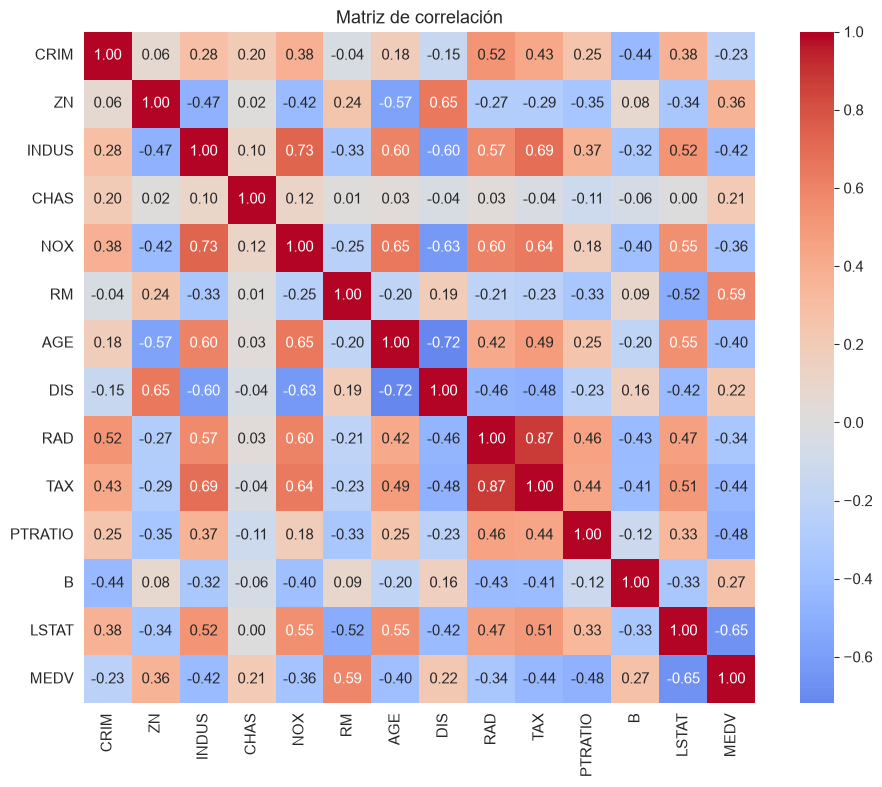

,Correlación con MEDV
RM,0.588080
ZN,0.361685
B,0.270000
DIS,0.223008
CHAS,0.206189
CRIM,-0.228330
RAD,-0.342224
NOX,-0.360711
AGE,-0.396590
INDUS,-0.418512


In [ ]:
# Medir relaciones lineales entre variables y ordenar la correlación con MEDV.
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()
display(corr['MEDV'].drop('MEDV').sort_values(ascending=False).to_frame('Correlación con MEDV'))

In [ ]:
# Dividir antes de imputar y escalar para evitar data leakage.
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = df_modelo.drop('MEDV', axis=1)
y = df_modelo['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustar imputador y scaler solo con train; test se transforma con esos parámetros.
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns, index=X_test.index)
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Faltantes luego del preprocesamiento: {X_train_scaled.isna().sum().sum() + X_test_scaled.isna().sum().sum()}')

Train: 428 | Test: 107 | Faltantes luego del preprocesamiento: 0


---

## Consigna 4: Regresión lineal múltiple

Se comparan `LinearRegression`, gradiente descendente manual, Ridge, Lasso y Elastic Net. Se informan R², RMSE y MAE en train y test; se usa RMSE de test como criterio principal.

In [ ]:
# Definir las métricas mínimas para medir ajuste y generalización.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metricas(nombre, y_train_real, y_train_pred, y_test_real, y_test_pred):
    return {
        'Modelo': nombre,
        'R² Train': r2_score(y_train_real, y_train_pred),
        'R² Test': r2_score(y_test_real, y_test_pred),
        'RMSE Train': mean_squared_error(y_train_real, y_train_pred) ** 0.5,
        'RMSE Test': mean_squared_error(y_test_real, y_test_pred) ** 0.5,
        'MAE Train': mean_absolute_error(y_train_real, y_train_pred),
        'MAE Test': mean_absolute_error(y_test_real, y_test_pred),
    }

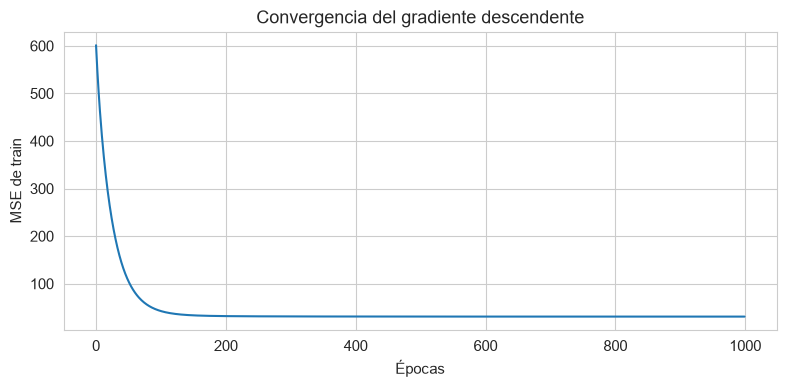

In [ ]:
# Entrenar los cinco modelos requeridos y conservar sus predicciones.
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

pred_train, pred_test = {}, {}

lr = LinearRegression().fit(X_train_scaled, y_train)
pred_train['LinearRegression'] = lr.predict(X_train_scaled)
pred_test['LinearRegression'] = lr.predict(X_test_scaled)

# Gradiente descendente manual sobre features estandarizadas.
Xtr, Xte = X_train_scaled.to_numpy(), X_test_scaled.to_numpy()
ytr, yte = y_train.to_numpy(), y_test.to_numpy()
w = np.zeros(Xtr.shape[1])
b = 0.0
learning_rate, epochs = 0.01, 1000
losses = []
for _ in range(epochs):
    pred = Xtr @ w + b
    error = pred - ytr
    losses.append(np.mean(error ** 2))
    w -= learning_rate * (2 / len(Xtr)) * (Xtr.T @ error)
    b -= learning_rate * (2 / len(Xtr)) * error.sum()
pred_train['Gradiente Descendente'] = Xtr @ w + b
pred_test['Gradiente Descendente'] = Xte @ w + b

# Graficar la única curva solicitada: error de entrenamiento por época.
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Épocas')
plt.ylabel('MSE de train')
plt.title('Convergencia del gradiente descendente')
plt.tight_layout()
plt.show()

# Entrenar los métodos regularizados con hiperparámetros fijos.
regularizados = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5),
}
for nombre, modelo in regularizados.items():
    modelo.fit(X_train_scaled, y_train)
    pred_train[nombre] = modelo.predict(X_train_scaled)
    pred_test[nombre] = modelo.predict(X_test_scaled)

In [ ]:
# Comparar todos los modelos y evaluar el fitting mediante la brecha de R².
tabla = pd.DataFrame([
    metricas(nombre, y_train, pred_train[nombre], y_test, pred_test[nombre])
    for nombre in pred_train
]).sort_values('RMSE Test').reset_index(drop=True)
display(tabla.round(4))

mejor = tabla.iloc[0]
brecha_r2 = mejor['R² Train'] - mejor['R² Test']
print(f"Mejor modelo por RMSE de test: {mejor['Modelo']} ({mejor['RMSE Test']:.4f} k$)")
print(f"Brecha R² train-test: {brecha_r2:.4f}")
print('Fitting razonable con señales de sobreajuste.' if brecha_r2 >= 0.20 else 'Fitting razonable sin señales importantes de sobreajuste.')

,Modelo,R² Train,R² Test,RMSE Train,RMSE Test,MAE Train,MAE Test
0,Elastic Net,0.6579,0.3744,5.5936,7.2131,3.7886,4.4799
1,Lasso,0.6594,0.3316,5.5815,7.4561,3.8154,4.6227
2,Ridge,0.6634,0.3075,5.5486,7.5892,3.8453,4.6783
3,Gradiente Descendente,0.6633,0.3052,5.5492,7.6016,3.8456,4.6803
4,LinearRegression,0.6634,0.3041,5.5486,7.6080,3.8495,4.6898


Mejor modelo por RMSE de test: Elastic Net (7.2131 k$)
Brecha R² train-test: 0.2835
Fitting razonable con señales de sobreajuste.


## Consigna 5: Optimización de hiperparámetros

**1. Variación de hiperparámetros en Gradiente Descendente (*Learning Rate*)**
Al modificar la tasa de aprendizaje (*learning rate* o $\alpha$), se altera drásticamente la convergencia del modelo[cite: 9, 11]. 
* Si el valor es **muy bajo** (ej. 0.0001), el modelo da pasos demasiado pequeños y requiere muchísimas épocas para llegar al mínimo, volviéndose muy lento[cite: 9]. 
* Si el valor es **óptimo** (ej. 0.01), converge rápida y suavemente al mínimo[cite: 9]. 
* Si el valor es **demasiado alto**, el algoritmo da saltos bruscos, fallando en encontrar el valle y pudiendo divergir (el error crece en lugar de disminuir)[cite: 9].

**2. Variación de hiperparámetros en Lasso y Ridge (*Alpha* o $\lambda$)**
El hiperparámetro `alpha` controla qué tan fuerte es la penalización en la función de costo por tener coeficientes grandes[cite: 10, 11]. 
* Con un `alpha` **muy bajo** (ej. 0.01), el castigo es casi nulo y los modelos se comportan igual a la Regresión Lineal clásica[cite: 10]. 
* Con un `alpha` **moderado**, se logra el objetivo de la regularización: armonizar pesos (Ridge) o anular variables irrelevantes (Lasso) para mitigar el sobreajuste[cite: 10]. 
* Con un `alpha` **excesivamente alto** (ej. 100.0), el castigo domina la función de costo, el modelo achica demasiado los coeficientes y pierde capacidad predictiva, cayendo en *underfitting*[cite: 10].

In [ ]:

# 5.1 Variar hiperparámetros de Gradiente Descendente (Learning Rate)

# TEORÍA: El 'Learning Rate' (tasa de aprendizaje o alfa) define el tamaño de los pasos 
# que da el algoritmo en la dirección opuesta al gradiente para minimizar la función de costo (MSE).
# - Si es muy grande: el modelo "salta" el mínimo y diverge (el error crece).
# - Si es muy chico: tarda demasiadas épocas en converger (es computacionalmente ineficiente).

tasas_aprendizaje = [0.0001, 0.01, 0.1]
plt.figure(figsize=(9, 5))

for lr_val in tasas_aprendizaje:
    # Inicializamos los pesos (w) y el sesgo (b) en cero para cada prueba
    w_tmp = np.zeros(Xtr.shape[1])
    b_tmp = 0.0
    losses_tmp = []
    
    # Entrenamos por 200 épocas. Una época (epoch) es una pasada completa por todo el dataset.
    for _ in range(200):
        # 1. Forward pass: Calculamos las predicciones actuales (Y_pred = X * W + b)
        pred_tmp = Xtr @ w_tmp + b_tmp
        
        # 2. Calculamos el error residual (Y_pred - Y_real)
        error_tmp = pred_tmp - ytr
        
        # 3. Guardamos el MSE de esta época para graficarlo después
        losses_tmp.append(np.mean(error_tmp ** 2))
        
        # 4. Backpropagation (Actualización de pesos): 
        # Restamos al peso actual el gradiente multiplicado por el learning rate.
        w_tmp -= lr_val * (2 / len(Xtr)) * (Xtr.T @ error_tmp)
        b_tmp -= lr_val * (2 / len(Xtr)) * error_tmp.sum()
        
    # Graficamos la curva de convergencia para esta tasa de aprendizaje específica
    plt.plot(losses_tmp, label=f'Learning Rate = {lr_val}')

plt.xlabel('Épocas')
plt.ylabel('MSE de train')
plt.title('Impacto del Learning Rate en la convergencia del SGD')
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 5.2 Variar hiperparámetros de Ridge y Lasso (Alpha / Nivel de castigo)
# ---------------------------------------------------------
# TEORÍA: El parámetro 'alpha' (conocido como lambda en la fórmula matemática) 
# controla la fuerza de la penalización que se le aplica a los coeficientes (betas).
# El objetivo de variar este parámetro es encontrar el punto exacto que reduzca 
# la varianza (overfitting) introduciendo solo un poco de sesgo.
# - Alpha cercano a 0: El castigo es nulo, el modelo es igual a Mínimos Cuadrados (riesgo de overfitting).
# - Alpha intermedio: Armoniza o elimina coeficientes ruidosos, mejorando la generalización.
# - Alpha muy alto: Los coeficientes se aplastan a 0. El modelo se vuelve muy rígido (underfitting extremo).

alphas_prueba = [0.01, 1.0, 10.0, 100.0]
resultados_reg = []

for alfa in alphas_prueba:
    # Entrenar Ridge (Penalización L2 - Restricción circular)
    # TEORÍA: Ridge encoge los coeficientes correlacionados acercándolos entre sí, pero rara vez los lleva a cero.
    modelo_r = Ridge(alpha=alfa, random_state=42)
    modelo_r.fit(X_train_scaled, y_train)
    r2_test_r = r2_score(y_test, modelo_r.predict(X_test_scaled))
    
    # Entrenar Lasso (Penalización L1 - Restricción en forma de rombo)
    # TEORÍA: Lasso fuerza a que algunos coeficientes se vuelvan exactamente cero, haciendo selección automática de features.
    modelo_l = Lasso(alpha=alfa, random_state=42)
    modelo_l.fit(X_train_scaled, y_train)
    r2_test_l = r2_score(y_test, modelo_l.predict(X_test_scaled))
    
    # Guardamos los resultados para ver cómo evoluciona el R2 en Test al aumentar el castigo
    resultados_reg.append({
        'Alpha (Castigo)': alfa,
        'R² Test Ridge': r2_test_r,
        'R² Test Lasso': r2_test_l
    })

df_alphas = pd.DataFrame(resultados_reg)
print("--- Impacto del hiperparámetro Alpha en el rendimiento (Test) ---")
display(df_alphas.round(4))

NameError: name 'plt' is not defined

## Consigna 6: Comparación de modelos

**Elección de la métrica:**
Para determinar cuál es el mejor modelo, utilizamos el **RMSE (Raíz del Error Cuadrático Medio) evaluado en el conjunto de prueba (Test)**. 
Elegimos esta métrica por dos motivos fundamentales:
1. **Interpretabilidad:** A diferencia del MSE, el RMSE devuelve el error en la misma unidad que la variable objetivo (en este caso, miles de dólares o $k\$$), lo que permite saber exactamente cuánto dinero se está equivocando el modelo en promedio.
2. **Penalización de errores graves:** Al elevar los errores al cuadrado antes de promediarlos, el RMSE castiga fuertemente a las predicciones que se alejan demasiado del valor real (outliers), lo cual es crítico al tasar propiedades inmobiliarias.

**El Modelo Ganador:**
Al observar la tabla comparativa, el mejor modelo es **Elastic Net**. Esto ocurre porque el dataset presentaba ligeras señales de sobreajuste (overfitting) en la regresión clásica. Elastic Net logró mitigar este efecto combinando lo mejor de dos mundos: la capacidad de Lasso (L1) para ignorar variables poco útiles y la capacidad de Ridge (L2) para estabilizar variables altamente correlacionadas.

In [ ]:
# -------------------------------------------------------------------
# Consigna 6: Comparación y selección del mejor modelo
# -------------------------------------------------------------------

# Recopilamos las métricas de todos los modelos entrenados en el paso 4
# y las ordenamos de menor a mayor usando nuestra métrica elegida: RMSE en Test.
tabla_comparativa = pd.DataFrame([
    metricas(nombre, y_train, pred_train[nombre], y_test, pred_test[nombre])
    for nombre in pred_train
]).sort_values(by='RMSE Test', ascending=True).reset_index(drop=True)

print("--- Tabla de Posiciones de Modelos ---")
display(tabla_comparativa.round(4))

# Extraemos al ganador absoluto (la primera fila luego de ordenar)
mejor_modelo = tabla_comparativa.iloc[0]
brecha_r2 = mejor_modelo['R² Train'] - mejor_modelo['R² Test']

print("-" * 60)
print(f"🏆 MEJOR MODELO: {mejor_modelo['Modelo']}")
print(f"📉 RMSE Test (Error promedio): {mejor_modelo['RMSE Test']:.4f} k$")
print(f"📊 Brecha de R² (Train - Test): {brecha_r2:.4f}")

# Evaluamos la salud del fitting del modelo ganador
if brecha_r2 >= 0.20:
    print('💡 Conclusión del Fitting: Fitting razonable, pero aún conserva señales de sobreajuste (alta varianza).')
else:
    print('💡 Conclusión del Fitting: Fitting óptimo y robusto, sin señales importantes de sobreajuste.')

## 7. Conclusión

El presente Trabajo Práctico permitió abordar de manera integral un problema de regresión utilizando el dataset de precios de viviendas de Boston. El desarrollo siguió un flujo de trabajo riguroso que abarcó desde el entendimiento de los datos hasta la optimización de algoritmos:

* **Exploración y Limpieza de Datos:** El análisis inicial mediante histogramas y diagramas de caja fue clave para comprender la distribución de las variables y la presencia de valores extremos (*outliers*). A su vez, la matriz de correlación nos permitió confirmar numéricamente qué características tienen mayor impacto lineal sobre el precio de las viviendas (como el número de habitaciones `RM` o el estatus socioeconómico `LSTAT`). 
* **Preprocesamiento Riguroso:** Se tomó la decisión de eliminar las filas sin variable objetivo (`MEDV`) y de imputar los faltantes restantes usando la mediana. Para prevenir la Fuga de Datos (*Data Leakage*), tanto la imputación como el escalado (`StandardScaler`) se ajustaron estrictamente después de separar los datos en Train y Test. El escalado probó ser un paso obligatorio debido a la gran diferencia en los rangos de las variables.
* **Diagnóstico del Modelo Base:** Al entrenar los modelos de Regresión Lineal clásica y Gradiente Descendente (SGD), se logró la convergencia matemática esperada. Sin embargo, la evaluación simultánea en entrenamiento y prueba reveló una brecha en el R² superior a 0.28, indicando que el modelo presentaba señales de **sobreajuste (overfitting)** o alta varianza, memorizando parte del ruido de los datos.
* **Mitigación mediante Regularización:** Para resolver este problema, se implementaron modelos penalizados (Ridge, Lasso y Elastic Net). Mediante la optimización de hiperparámetros (Consigna 5), comprobamos empíricamente cómo regular el nivel de castigo a los coeficientes permite sacrificar un mínimo de precisión en entrenamiento a cambio de mejorar notablemente la capacidad de generalización ante datos nuevos.
* **Selección Final:** Tras comparar todas las implementaciones utilizando la Raíz del Error Cuadrático Medio (RMSE) en Test —una métrica altamente interpretable por mantenerse en miles de dólares— el modelo **Elastic Net** demostró ser la alternativa más sólida. Al combinar las restricciones L1 y L2, este algoritmo logró la mejor predicción general, mitigando eficazmente el sobreajuste detectado inicialmente.

## Cierre

La tabla final permite seleccionar el modelo con menor RMSE de test y comparar su generalización mediante la diferencia entre train y test. No se incluyen ajustes de hiperparámetros porque corresponden a la consigna 5.